Data sources: [Statistics Canada](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1310083701) <i>("download entire table as CSV")</i><br>
[List of Canadian provinces and territories by life expectancy](https://en.wikipedia.org/wiki/List_of_Canadian_provinces_and_territories_by_life_expectancy) / [Продолжительность жизни в провинциях и территориях Канады](https://ru.wikipedia.org/wiki/Продолжительность_жизни_в_провинциях_и_территориях_Канады)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import math
import re
from collections import namedtuple

In [3]:
pd.options.display.min_rows=8
# pd.options.display.max_rows=110

In [4]:
LANGS = ['en']  # languages of the charts (this setting doesn't have influence on tables)  #['en', 'ru', 'fr', 'nolang']
YEAR = 2019
EXPLORE_PERIOD = True  # Change this value to 'False' to speed up work of the script, if the exploration is not required
WRITE_TABLE = False
DESTINATION_CHART = 'show'  # to where table code should be placed: 'file', 'show'

REGION_1 = 'Ontario'
REGION_2 = 'Quebec'
REGION_3 = 'British Columbia'

<br>

In [6]:
# For overview, explore probability of dying at certain age during a some period
def explore_change_of_probability_for_given_age(age_to_explore: str, region_to_explore='Canada'):
    df = pd.read_csv('data/Canada-1year-2024.zip', compression='zip',
                 usecols = ['REF_DATE', 'GEO', 'Age group', 'Sex', 'Element', 'VALUE'])

    df= df.loc[(df['GEO'] == region_to_explore) &
               (df['Age group'] == age_to_explore) &
               (df['Element'] == 'Death probability between age x and x+1 (qx)')]

    df = df.drop(columns=['GEO', 'Age group', 'Element']) \
           .rename(columns={'REF_DATE': 'year',
                            'Sex': 'sex',
                            'VALUE': 'value'})

    df['value'] = df['value'] * 100

    df = pd.pivot_table(df, values='value', index='year', columns='sex')

    df.rename(columns={'Both sexes':'total', 'Males':'male', 'Females':'female'}, inplace=True)
    df = df[['male', 'total', 'female']]
    df['mΔf'] = df['male'] - df['female']
    df['ratio_mf'] = (df['male'] / df['female']).round(2)

    df.index.name = ''
    df.columns.name = ''

    return df


age_to_explore = '109 years'
df_to_explore = pd.DataFrame()
if EXPLORE_PERIOD:
    df_to_explore = explore_change_of_probability_for_given_age(age_to_explore)
df_to_explore.loc[2000:]

,male,total,female,mΔf,ratio_mf
,,,,,
2000,51.251,48.667,50.321,0.930,1.02
2001,52.315,49.819,50.762,1.553,1.03
2002,53.102,50.119,50.758,2.344,1.05
2003,52.639,49.969,50.800,1.839,1.04
2004,52.609,50.195,51.040,1.569,1.03
2005,53.076,50.304,50.965,2.111,1.04
2006,52.627,49.636,50.274,2.353,1.05
2007,52.550,49.876,50.582,1.968,1.04
2008,52.571,49.511,50.162,2.409,1.05


<br>

<h4>Basic calculations</h4>

In [8]:
# load data
df = pd.read_csv('data/Canada-1year-2024.zip', compression='zip',
                 usecols = ['REF_DATE', 'GEO', 'Age group', 'Sex', 'Element', 'VALUE'])

df= df.loc[(df['REF_DATE'] == YEAR) & (df['Element'] == 'Death probability between age x and x+1 (qx)')]

df.head(2)

,REF_DATE,GEO,Age group,Sex,Element,VALUE
1168832,2019,Canada,0 years,Both sexes,Death probability between age x and x+1 (qx),0.00438
1168841,2019,Canada,0 years,Males,Death probability between age x and x+1 (qx),0.00488


In [9]:
# filter dataFrame
df = df.drop(columns=['REF_DATE', 'Element']) \
       .rename(columns={'GEO': 'region',
                        'Age group': 'age',
                        'Sex': 'sex',
                        'VALUE': 'value'})

df['age'] = df['age'].replace({'110 years and over' : '110', '1 year' : '1'}) \
                     .map(lambda st: st.replace(' years', ''))  \
                     .astype(int)

df['value'] = df['value'] * 100

df

,region,age,sex,value
1168832,Canada,0,Both sexes,0.438
1168841,Canada,0,Males,0.488
1168850,Canada,0,Females,0.386
1168859,Canada,1,Both sexes,0.024
...,...,...,...,...
1198766,British Columbia,109,Females,50.681
1198775,British Columbia,110,Both sexes,100.000
1198784,British Columbia,110,Males,100.000
1198793,British Columbia,110,Females,100.000


In [10]:
# check types of values in columns, just in case
df.dtypes

region     object
age         int32
sex        object
value     float64
dtype: object

<br>

In [12]:
# df.head(4)

In [13]:
def get_data_for_single_region(df, region, suffix_for_columns=''):
    df = df.loc[df['region'] == region] \
           .drop(columns=['region'])

    df = pd.pivot_table(df, values='value', index='age', columns='sex')

    df.rename(columns={'Both sexes':'total', 'Males':'male', 'Females':'female'}, inplace=True)
    df = df[['male', 'total', 'female']]
    df['mΔf'] = df['male'] - df['female']
    df['ratio_mf'] = (df['male'] / df['female']).round(2)

    df.columns = [f"{col_name}{suffix_for_columns}" for col_name in df.columns]
    
    return df


df = pd.concat([
        get_data_for_single_region(df, 'Canada'),
        get_data_for_single_region(df, REGION_1, '_r1'),
        get_data_for_single_region(df, REGION_2, '_r2'),
        get_data_for_single_region(df, REGION_3, '_r3')], axis='columns')
df.index.name = ''

# drop values for 110, since this record doesn't have sense
df.drop(index=110, inplace=True)

df.loc[[0, 1, 5]+list(range(10, 71, 10))+list(range(75, 106, 5))+[109]]

,male,total,female,mΔf,ratio_mf,male_r1,total_r1,female_r1,mΔf_r1,ratio_mf_r1,male_r2,total_r2,female_r2,mΔf_r2,ratio_mf_r2,male_r3,total_r3,female_r3,mΔf_r3,ratio_mf_r3
,,,,,,,,,,,,,,,,,,,,
0,0.488,0.438,0.386,0.102,1.26,0.476,0.447,0.417,0.059,1.14,0.490,0.406,0.318,0.172,1.54,0.367,0.330,0.290,0.077,1.27
1,0.026,0.024,0.022,0.004,1.18,0.022,0.020,0.019,0.003,1.16,0.030,0.022,0.015,0.015,2.00,0.015,0.021,0.019,-0.004,0.79
5,0.009,0.009,0.009,0.000,1.00,0.008,0.009,0.009,-0.001,0.89,0.006,0.007,0.007,-0.001,0.86,0.010,0.007,0.008,0.002,1.25
10,0.008,0.007,0.007,0.001,1.14,0.008,0.007,0.005,0.003,1.60,0.006,0.005,0.003,0.003,2.00,0.007,0.006,0.006,0.001,1.17
20,0.065,0.048,0.029,0.036,2.24,0.055,0.042,0.026,0.029,2.12,0.054,0.039,0.020,0.034,2.70,0.068,0.049,0.025,0.043,2.72
30,0.101,0.075,0.047,0.054,2.15,0.095,0.071,0.046,0.049,2.07,0.060,0.044,0.027,0.033,2.22,0.122,0.090,0.055,0.067,2.22
40,0.141,0.111,0.080,0.061,1.76,0.138,0.108,0.078,0.060,1.77,0.093,0.075,0.057,0.036,1.63,0.158,0.124,0.089,0.069,1.78
50,0.287,0.235,0.183,0.104,1.57,0.282,0.226,0.172,0.110,1.64,0.241,0.205,0.167,0.074,1.44,0.308,0.242,0.179,0.129,1.72
60,0.684,0.557,0.431,0.253,1.59,0.673,0.538,0.408,0.265,1.65,0.622,0.523,0.419,0.203,1.48,0.663,0.525,0.392,0.271,1.69


In [14]:
# alternative look at the result
df.loc[[0, 1, 5]+list(range(10, 71, 10))+list(range(75, 106, 5))+[109], ['male', 'male_r1', 'male_r2', 'male_r3', 'female', 'female_r1', 'female_r2', 'female_r3']]

,male,male_r1,male_r2,male_r3,female,female_r1,female_r2,female_r3
,,,,,,,,
0,0.488,0.476,0.490,0.367,0.386,0.417,0.318,0.290
1,0.026,0.022,0.030,0.015,0.022,0.019,0.015,0.019
5,0.009,0.008,0.006,0.010,0.009,0.009,0.007,0.008
10,0.008,0.008,0.006,0.007,0.007,0.005,0.003,0.006
20,0.065,0.055,0.054,0.068,0.029,0.026,0.020,0.025
30,0.101,0.095,0.060,0.122,0.047,0.046,0.027,0.055
40,0.141,0.138,0.093,0.158,0.080,0.078,0.057,0.089
50,0.287,0.282,0.241,0.308,0.183,0.172,0.167,0.179
60,0.684,0.673,0.622,0.663,0.431,0.408,0.419,0.392


<br>

<h4>Explore the "plateau"  (21–30 years)</h4>
The code below calculates average values of the probability of dying for the "plateau", and how much people would live if throughout their lifetime the probability of dying will be the same as in this interval.

In [16]:
# explore the the "plateau" manually, if we want
# df.loc[16:40]

In [17]:
# just for fun, calculate average values during the "plateau" for the country and the separate regions
plateau_years = slice(21, 30)

dfe = pd.concat([
    df.loc[plateau_years, ['male', 'total', 'female']].mean(),
    df.loc[plateau_years, ['male_r1', 'total_r1', 'female_r1']].mean().rename(index={'male_r1':'male', 'total_r1':'total', 'female_r1':'female'}),
    df.loc[plateau_years, ['male_r2', 'total_r2', 'female_r2']].mean().rename(index={'male_r2':'male', 'total_r2':'total', 'female_r2':'female'}),
    df.loc[plateau_years, ['male_r3', 'total_r3', 'female_r3']].mean().rename(index={'male_r3':'male', 'total_r3':'total', 'female_r3':'female'})
], axis='columns').T
dfe['ratio_mf'] = (dfe['male'] / dfe['female']).round(2)
dfe.index = ['Canada', REGION_1, REGION_2, REGION_3]
dfe.round(3)

,male,total,female,ratio_mf
Canada,0.087,0.063,0.038,2.32
Ontario,0.078,0.057,0.034,2.26
Quebec,0.059,0.041,0.022,2.69
British Columbia,0.103,0.073,0.041,2.52


In [18]:
# calculate average life expectancy if during the whole life of people the mortality rate will the the same as at the "plateau"
def calculate_average_LE_if_mortality_as_at_plateau(mortality_in_perc):
    mortality = mortality_in_perc / 100
    average_le = 1 / mortality
    return int(average_le)

dfe['le_ageless_male'] = dfe['male'].map(calculate_average_LE_if_mortality_as_at_plateau)
dfe['le_ageless_total'] = dfe['total'].map(calculate_average_LE_if_mortality_as_at_plateau)
dfe['le_ageless_female'] = dfe['female'].map(calculate_average_LE_if_mortality_as_at_plateau)
# dfe['ratio_ageless'] = (dfe['le_ageless_female'] / dfe['le_ageless_male']).round(2)  # values the same as in the columns 'ratio_mf'
dfe.round(3)

,male,total,female,ratio_mf,le_ageless_male,le_ageless_total,le_ageless_female
Canada,0.087,0.063,0.038,2.32,1149,1584,2666
Ontario,0.078,0.057,0.034,2.26,1283,1751,2898
Quebec,0.059,0.041,0.022,2.69,1694,2415,4566
British Columbia,0.103,0.073,0.041,2.52,970,1369,2450


<br>

<h4>Explore the zone of the Gompertz law of mortality  (40–90 years)</h4>
The code below calculates the average annual increase the probability of dying (in percent) and the period during that this indicator doubles (in years), <b>based on the values at the endpoints</b>.<br><i>
(Calculations based on approximation are below, under a chart.)</i>

In [20]:
def calculate_increase_rate_and_doubling_period(age1: int, age2: int, v1: float, v2: float):
    '''
    This function calculate two characteristics of a geometric progression (in the context of aging)
    - by what percentage does the value increase every year (in percent)
    - period of doubling (in years)
    '''
    q = math.pow((v2 / v1),
                  1 / (age2 - age1))  # find 'common ratio' of the geometric progression
                                      # (age2 - age1) √ (v2 / v1)      – (age2-age1)th root of (v2 / v1)

    T = math.log(2, q)  # doubling period:    log base 'q' of 2
    return (q - 1) * 100, T

In [21]:
age_gompertz_start = 40
age_gompertz_stop  = 90
print("           increase_rate(%)  doubling    | increase_rate(%)  doubling")
print("                        male             |            female")
for region, pref in zip(['Canada', REGION_1, REGION_2, REGION_3], ['', '_r1', '_r2', '_r3']): 
    male_rate_perc, male_period_double = \
        calculate_increase_rate_and_doubling_period(
            age_gompertz_start, age_gompertz_stop, df.loc[age_gompertz_start, 'male'+pref], df.loc[age_gompertz_stop, 'male'+pref])
    female_rate_perc, female_period_double = \
        calculate_increase_rate_and_doubling_period(
            age_gompertz_start, age_gompertz_stop, df.loc[age_gompertz_start, 'female'+pref], df.loc[age_gompertz_stop, 'female'+pref])
    print(f"{region:16}: {male_rate_perc:5.2f} %  {male_period_double:5.2f} years   |" +
          f"      {female_rate_perc:5.2f} %  {female_period_double:5.2f} years")

           increase_rate(%)  doubling    | increase_rate(%)  doubling
                        male             |            female
Canada          :  9.69 %   7.50 years   |      10.32 %   7.06 years
Ontario         :  9.68 %   7.50 years   |      10.32 %   7.06 years
Quebec          : 10.63 %   6.86 years   |      11.08 %   6.59 years
British Columbia:  9.31 %   7.79 years   |      10.04 %   7.24 years


<br>

In [23]:
def create_table(df, file_header, lang='en'):

    def transform_value(x, prec=1):
        return f"{x:0.{prec}f}"

    
    with open('design/' + file_header, mode='r', encoding="utf-8") as fh:
        table_header = fh.read()

    st = ''
    prec = 3
    for age in [0, 1] + list(range(5, 106, 5)) + [109]:
        ser = df.loc[age]
        st += '\n' + '|-\n' + \
            f'|style="padding-right:3ex;"| {age} ' + \
            f'||style="color:blue;padding-right:3ex;"| {transform_value(ser.loc['male'], prec=prec)} ' + \
            f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['female'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf']:0.2f} ' + \
            f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['male_r1'], prec=prec)} ' + \
            f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['female_r1'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf_r1']:0.2f} ' + \
            f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['male_r2'], prec=prec)} ' + \
            f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['female_r2'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf_r2']:0.2f} ' + \
            f'||style="color:blue;padding-right:3ex;border-left-width:2px;"| {transform_value(ser.loc['male_r3'], prec=prec)} ' + \
            f'||style="color:red;padding-right:3ex;"| {transform_value(ser.loc['female_r3'], prec=prec)} ' + \
            f'||style="color:darkgray;"| {ser.loc['ratio_mf_r3']:0.2f}'

    # fix microbugs that can happened due to nuances of calculations and rounding
    st = st.replace('color:darkgray;padding-right:3ex;"| -0.0 ', 'color:darkgray;padding-right:3ex;"| 0.0 ')

    if lang == 'ru':
        st = re.sub('(?<=\\d)\\.(?=\\d)', ',', st)  # replace . to comma, if this . is between two digits
        st = st.replace('padding-right:3ex;', 'padding-right:2.5ex;')

    st = table_header + st + '\n|}'
    return st
        

if WRITE_TABLE:
    table_code = create_table(df, file_header='Probability_of_dying_extended -en.txt', lang='en')
    with open(f"output/Table code for probability of dying extended -{YEAR} -en.txt", 'w', encoding="utf-8") as fh:
        fh.write(table_code)

    table_code = create_table(df, file_header='Probability_of_dying_extended -ru.txt', lang='ru')
    with open(f"output/Table code for probability of dying extended -{YEAR} -ru.txt", 'w', encoding="utf-8") as fh:
        fh.write(table_code)

<br>
<br>

In [25]:
DisplayedGroup = namedtuple('DisplayedGroup', ['en_name', 'ru_name', 'fr_name', 'nolang_name', 'color', 'style', 'width', 'alpha'])

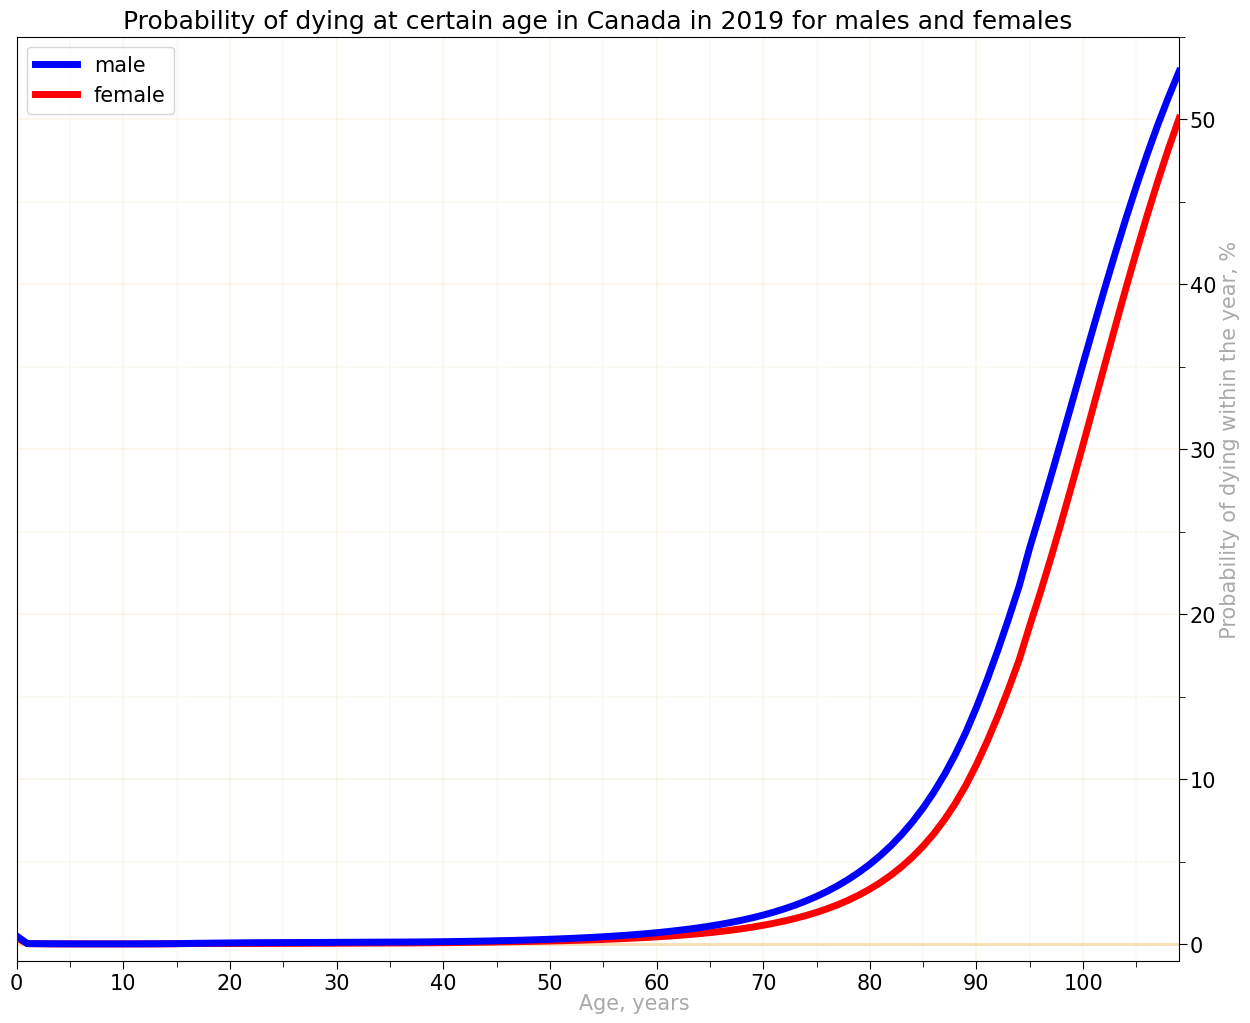

In [26]:
def create_chart(
        df, lang='en', dd_display='', ncol=1,
        title_en="Title of the chart", title_ru="Заголовок графика", title_fr="Titre du graphique",
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.yaxis.tick_right()      # show ticks only at the left side
    ax.yaxis.set_label_position('right')  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(5))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)   # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)          # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5) # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)          # Minor ticks are shorter
    plt.xticks(fontsize=15)   # font size for tick labels
    plt.yticks(fontsize=15)
    
    x_min = y_min = 0
    x_max = 109
    y_max = 55
    plt.xlim(0, 109)
    plt.ylim(-1, 55)

    plt.grid(which='major', color='wheat', linewidth=0.35)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    plt.axhline(y=0, color='wheat', linewidth=2)

    plt.title(title_ru if lang=='ru' else title_fr if lang=='fr' else " " if lang=='nolang' else title_en, fontsize=18)
    plt.xlabel("               Возраст, годы" if lang=='ru' else
               "               Âge, années" if lang=='fr' else
               " " if lang=='nolang' else
               "           Age, years",
               fontsize=15, color='darkgray', labelpad=0)
    plt.ylabel("          Вероятность смерти в течение года, %" if lang=='ru' else
               "       Probabilité de décès dans un an, %" if lang=='fr' else
               " " if lang=='nolang' else
               "                  Probability of dying within the year, %",
               fontsize=15, color='darkgray', labelpad=3)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].fr_name if lang=='fr' else dd_display[gr].nolang_name if lang=='nolang' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    plt.legend(loc='upper left', fontsize=15, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ' -fr' if lang=='fr' else ' -nolang' if lang=='nolang' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print("Data has written to file")
    else:
        plt.show()


dd_display = {
    'male'  : DisplayedGroup(en_name="male",   ru_name="мужчины", fr_name="hommes", nolang_name="♂", color='blue', style='-', width=5, alpha=1),
    # 'total' : DisplayedGroup(en_name="overall", ru_name="в целом", nolang_name="∑", color='lightgrey', style='-', width=5, alpha=1),
    'female': DisplayedGroup(en_name="female", ru_name="женщины", fr_name="femmes", nolang_name="♀", color='red',  style='-', width=5, alpha=1)
}

for lang in LANGS:
    create_chart(df.T.loc[['male', 'female']],
            dd_display=dd_display, lang=lang,
            title_en=f"Probability of dying at certain age in Canada in {YEAR} for males and females",  # , overall statistics for males and females
            title_ru=f"Вероятность смерти в определённом возрасте в Канаде в {YEAR} для мужчин и женщин",
            title_fr=f"Probabilité de décès selon l’âge au Canada en {YEAR} chez les hommes et les femmes", 
            file_name=f"Probability of Dying at Certain Age in Canada in {YEAR}")

  —— The zone of the 'plateau' (21–30 years, incl.) ——
Average mortality rate at the plateau, %:  ♂: 0.087,  ♀: 0.037
Life expectancy based on the average mortality rate at the plateau, years:  ♂: 1150,  ♀: 2670

  —— The zone of the Gompertz law of mortality (40–90 age_gompertz_stop) ——
Model for   male: y = 0.002721 * exp(0.093446 * x)
Coefficient of determination (R²): 0.982
Annual increase:  9.795 %,   doubling period:  7.418 years

Model for female: y = 0.001381 * exp(0.097323 * x)
Coefficient of determination (R²): 0.970
Annual increase: 10.222 %,   doubling period:  7.122 years



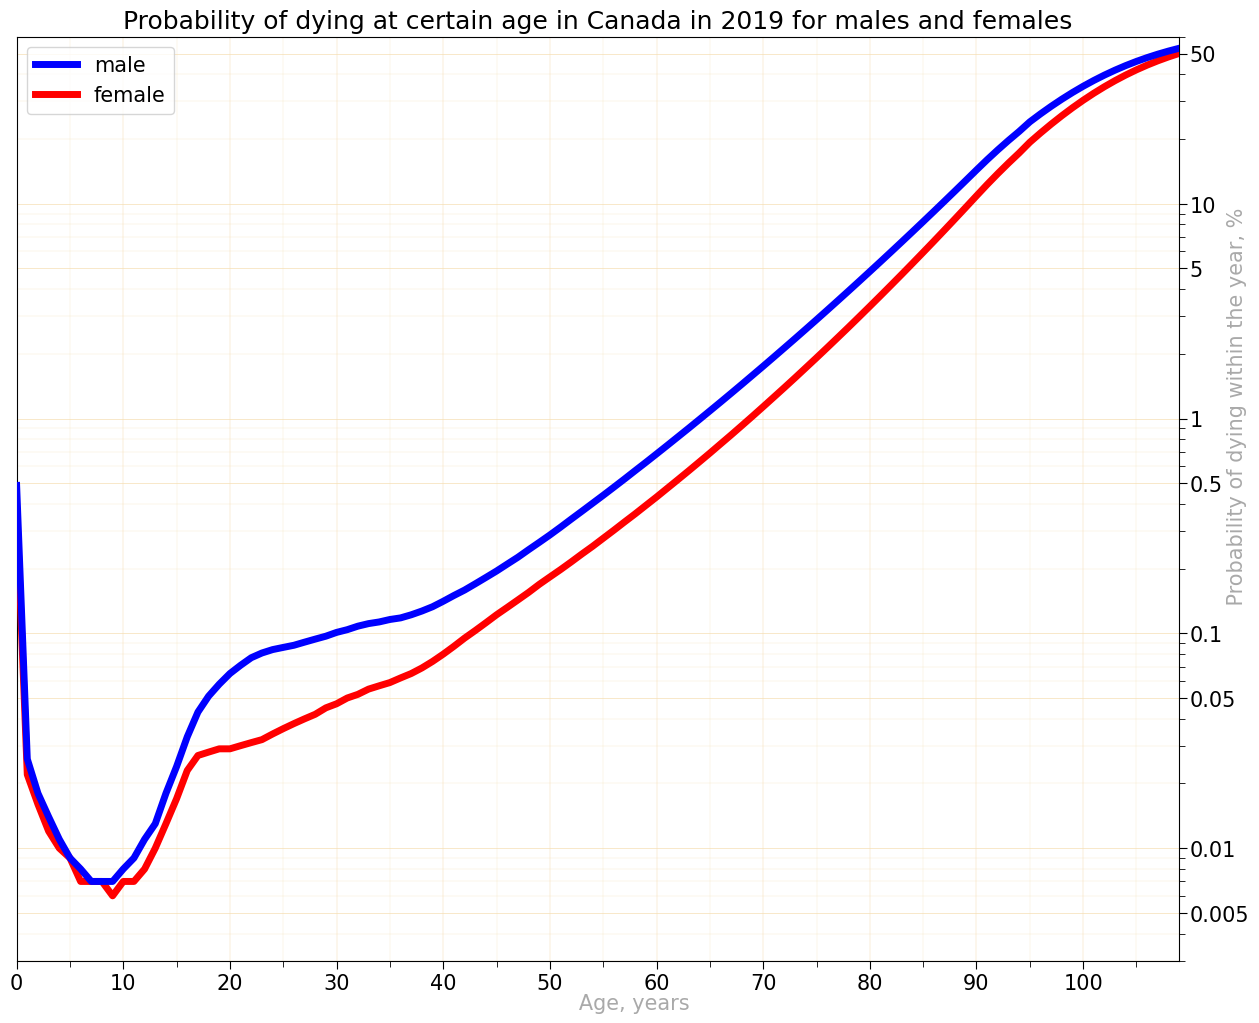

In [27]:
def create_chart_log(
        df, lang='en', dd_display='', ncol=1,
        plateau_years=plateau_years, show_plateau=False,
        age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=True,
        title_en="Title of the chart", title_ru="Заголовок графика", title_fr="Titre du graphique",
        destination=DESTINATION_CHART, file_name=''):

    plt.rcParams['figure.figsize'] = (15, 12)
    
    fig, ax = plt.subplots()   # Create a figure and axis
    ax.set_yscale('log')       # Make Y-axis logarithmic  # alternative: plt.yscale('log')
    
    ax.yaxis.tick_right()                 # show ticks only at the left side
    ax.yaxis.set_label_position('right')  # set the label position to the right 

    ax.xaxis.set_major_locator(MultipleLocator(10))   # Set major ticks to be multiples of 10
    ax.xaxis.set_minor_locator(MultipleLocator(5))    # Set minor ticks to be multiples of 5
    # ax.yaxis.set_major_locator(ticker.LogLocator())
    # ax.yaxis.set_minor_locator(ticker.LogLocator(subs=np.arange(1, 10) * 0.1))

    # Customize tick lengths
    ax.tick_params(axis='x', which='major', length=6, pad=3)   # Major ticks are longer
    ax.tick_params(axis='x', which='minor', length=4)          # Minor ticks are shorter
    ax.tick_params(axis='y', which='major', length=6, pad=1.5) # Major ticks are longer
    ax.tick_params(axis='y', which='minor', length=4)          # Minor ticks are shorter
    plt.xticks(fontsize=15)                                    # font size for tick labels
    labels_y = [0.005, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]
    plt.yticks(ticks=labels_y, labels=labels_y, fontsize=15)
    
    x_min = y_min = 0
    x_max = 109
    y_max = 60
    plt.xlim(0, 109)
    plt.ylim(0.003, 60)

    plt.grid(which='major', axis='x', color='wheat', linewidth=0.35)
    plt.grid(which='major', axis='y', color='wheat', linewidth=0.5)
    plt.grid(which='minor', color='wheat', linewidth=0.20)

    # for y_milestone in [0.1, 1, 10]:
    #     plt.axhline(y=y_milestone, color='wheat', linewidth=0.5)

    plt.title(title_ru if lang=='ru' else title_fr if lang=='fr' else " " if lang=='nolang' else title_en, fontsize=18)
    plt.xlabel("               Возраст, годы" if lang=='ru' else
               "               Âge, années" if lang=='fr' else
               " " if lang=='nolang' else
               "           Age, years",
               fontsize=15, color='darkgray', labelpad=0)
    plt.ylabel("                   Вероятность смерти в течение года, %" if lang=='ru' else
               "                         Probabilité de décès dans un an, %" if lang=='fr' else
               " " if lang=='nolang' else
               "                            Probability of dying within the year, %",
               fontsize=15, color='darkgray', labelpad=-16)
    
    for i, gr in enumerate(df.index.to_list()):
        ser = df.loc[gr]
        line_name = dd_display[gr].ru_name if lang=='ru' else dd_display[gr].fr_name if lang=='fr' else dd_display[gr].nolang_name if lang=='nolang' else dd_display[gr].en_name
        plt.plot(ser, color=dd_display[gr].color, linestyle=dd_display[gr].style,
                 linewidth=dd_display[gr].width, label=line_name, alpha=dd_display[gr].alpha, zorder=100-i)

    # Calculate and show statistics about "plateau" (21–30 years, including endpoints)
    print(f"  —— The zone of the 'plateau' ({plateau_years.start}–{plateau_years.stop} years, incl.) ——")

    plateau_mortality_male   = df.loc['male', plateau_years].mean()
    plateau_mortality_female = df.loc['female', plateau_years].mean()
    print(f"Average mortality rate at the plateau, %:  ♂: {plateau_mortality_male:.3f},  ♀: {plateau_mortality_female:.3f}")
    
    le_average_plateau_male   = calculate_average_LE_if_mortality_as_at_plateau(plateau_mortality_male)
    le_average_plateau_female = calculate_average_LE_if_mortality_as_at_plateau(plateau_mortality_female)
    print("Life expectancy based on the average mortality rate at the plateau, years:  " +
          f"♂: {round(le_average_plateau_male, -1)},  ♀: {round(le_average_plateau_female, -1)}" +
          '\n')

    if show_plateau:  # show horizontal lines for the "plateaux"
        for y_plateau in [plateau_mortality_male, plateau_mortality_female]:
             plt.hlines(y_plateau, plateau_years.start, plateau_years.stop, color='lime', linewidth=2, alpha=0.5)

    # Calculate and show statistics about the zone of the Gompertz law of mortality (40–90 years)
    print(f"  —— The zone of the Gompertz law of mortality ({age_gompertz_start}–{age_gompertz_stop} age_gompertz_stop) ——")

    # Generate x-values for the considered interval
    x_gompertz = np.linspace(age_gompertz_start, age_gompertz_stop, age_gompertz_stop-age_gompertz_start+1)

    for group in ['male', 'female']:
        y_gompertz = df.loc[group, x_gompertz].values    # take the y values
        ln_y = np.log(y_gompertz)                        # take the logarithm of the y values
        b, ln_a = np.polyfit(x_gompertz, ln_y, deg=1)    # do linear regression
                                                         #    b - slope of the line
                                                         #    b - intersection of the 'ln a' with the y-axis
        a = np.exp(ln_a)                                 # recover the amplitude of the exponent
        print(f"Model for {group:>6}: y = {a:.6f} * exp({b:.6f} * x)")

        y_fit = a * np.exp(b * x_gompertz)               # approximated function

        ss_res = np.sum((y_gompertz - y_fit) ** 2)                # calculate the coefficient of determination
        ss_tot = np.sum((y_gompertz - np.mean(y_gompertz)) ** 2)
        r2 = 1 - ss_res / ss_tot
        print(f"Coefficient of determination (R²): {r2:.3f}")

        rate_perc, period_double = calculate_increase_rate_and_doubling_period(
            x_gompertz[0], x_gompertz[-1], y_fit[0], y_fit[-1])
        print(f"Annual increase: {rate_perc:6.3f} %,   doubling period: {period_double:6.3f} years")
        print()

        if show_gompertz:  # show sloped lines for the zone where Gompertz law is observed
            plt.plot(x_gompertz, y_fit, color='orange', linewidth=dd_display[group].width, alpha=0.5)

    plt.legend(loc='upper left', fontsize=15, ncol=ncol)

    if destination == 'file':
        plt.savefig(f"output_charts/{file_name}{' -ru' if lang=='ru' else ' -fr' if lang=='fr' else ' -nolang' if lang=='nolang' else ''}.png", bbox_inches='tight', facecolor='white', pad_inches=0.05)
        print("Data has written to file")
    else:
        plt.show()


for lang in LANGS:
    create_chart_log(df.T.loc[['male', 'female']],
            dd_display=dd_display, lang=lang,
            plateau_years=plateau_years, show_plateau=False,
            age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=False,
            title_en=f"Probability of dying at certain age in Canada in {YEAR} for males and females",  # , overall statistics for males and females
            title_ru=f"Вероятность смерти в определённом возрасте в Канаде в {YEAR} для мужчин и женщин",
            title_fr=f"Probabilité de décès selon l’âge au Canada en {YEAR} chez les hommes et les femmes",
            file_name=f"Probability of Dying at Certain Age in Canada in {YEAR} -log")

  —— The zone of the 'plateau' (21–30 years, incl.) ——
Average mortality rate at the plateau, %:  ♂: 0.087,  ♀: 0.037
Life expectancy based on the average mortality rate at the plateau, years:  ♂: 1150,  ♀: 2670

  —— The zone of the Gompertz law of mortality (40–90 age_gompertz_stop) ——
Model for   male: y = 0.002721 * exp(0.093446 * x)
Coefficient of determination (R²): 0.982
Annual increase:  9.795 %,   doubling period:  7.418 years

Model for female: y = 0.001381 * exp(0.097323 * x)
Coefficient of determination (R²): 0.970
Annual increase: 10.222 %,   doubling period:  7.122 years



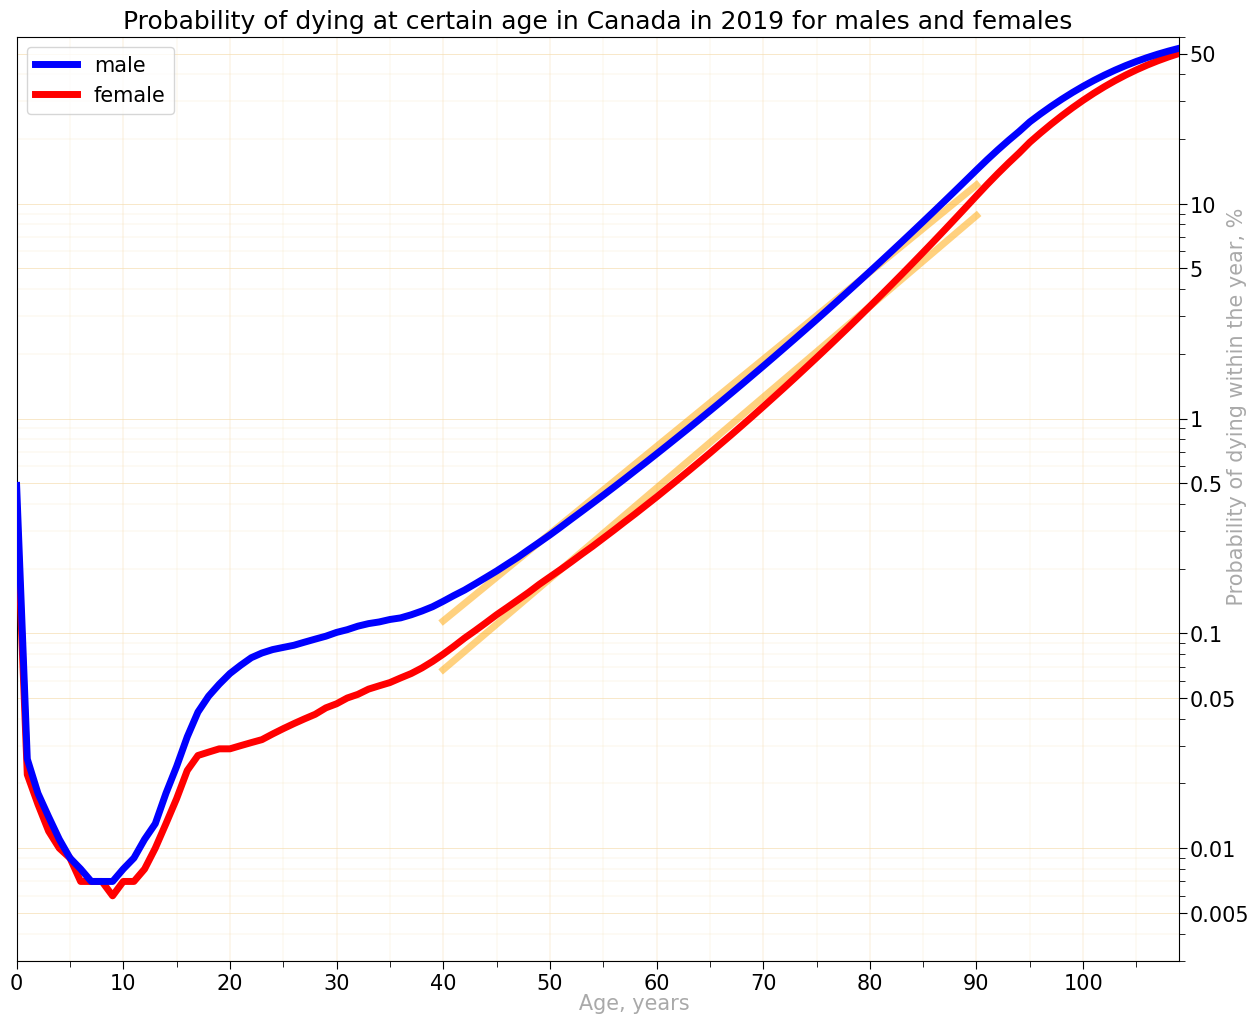

In [28]:
for lang in LANGS:
    create_chart_log(df.T.loc[['male', 'female']],
            dd_display=dd_display, lang=lang,
            plateau_years=plateau_years, show_plateau=False,
            age_gompertz_start=age_gompertz_start, age_gompertz_stop=age_gompertz_stop, show_gompertz=True,
            title_en=f"Probability of dying at certain age in Canada in {YEAR} for males and females",  # , overall statistics for males and females
            title_ru=f"Вероятность смерти в определённом возрасте в Канаде в {YEAR} для мужчин и женщин",
            title_fr=f"Probabilité de décès selon l’âge au Canada en {YEAR} chez les hommes et les femmes",
            file_name=f"Probability of Dying at Certain Age in Canada in {YEAR} -gompertz")

<br>
<br>

In [30]:
# play beep to denote completion of the program
import IPython.display as ipd
import numpy as np

# manually generated sound
t = 1  # time is seconds
beep = np.sin(2*np.pi*400*np.arange(10000*t)/10000)
ipd.Audio(beep, rate=10000, autoplay=True)